# 04. Noisy Test Generation

Notebook này ghi lại kết quả của **Stage 4 — Noisy Test Generation**.

Vai trò của notebook:

- Không sinh lại dữ liệu noisy.
- Không train model.
- Chỉ đọc output đã sinh ra từ `scripts/generate_noisy_tests.py`.
- Kiểm tra số dòng, mức độ thay đổi và ví dụ clean/noisy.
- Ghi nhận các biến thể noise dùng cho robustness evaluation.

Nguyên tắc thiết kế:

```text
- Chỉ làm nhiễu test set.
- Train và validation giữ nguyên.
- Label sentiment/topic được giữ nguyên từ clean test.
- Noisy test dùng để đánh giá độ bền, không dùng để train baseline/PhoBERT.
```

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

NOISY_DIR = ROOT / "data" / "noisy"
TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
REPORTS_DIR = ROOT / "outputs" / "reports"
PROCESSED_DIR = ROOT / "data" / "processed"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra output bắt buộc

Các file này phải tồn tại sau khi chạy:

```powershell
python scripts/generate_noisy_tests.py
```

In [2]:
required_files = {
    "clean_test": NOISY_DIR / "test_clean.csv",
    "noisy_all": NOISY_DIR / "test_noisy_all.csv",
    "eval_all": NOISY_DIR / "test_eval_all.csv",
    "summary": TABLES_DIR / "noisy_generation_summary.csv",
    "examples": TABLES_DIR / "noisy_text_examples.csv",
    "changed_percent_figure": FIGURES_DIR / "noisy_changed_percent_by_variant.png",
    "char_change_figure": FIGURES_DIR / "noisy_char_change_ratio_by_variant.png",
    "report": REPORTS_DIR / "noisy_generation_report.md",
    "config_snapshot": REPORTS_DIR / "noise_config_snapshot.json",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required Stage 4 files: {missing}")

print("All required Stage 4 files exist.")

,name,path,exists
0,clean_test,d:\project-ml-engineering\viedufeedback-robust...,True
1,noisy_all,d:\project-ml-engineering\viedufeedback-robust...,True
2,eval_all,d:\project-ml-engineering\viedufeedback-robust...,True
3,summary,d:\project-ml-engineering\viedufeedback-robust...,True
4,examples,d:\project-ml-engineering\viedufeedback-robust...,True
5,changed_percent_figure,d:\project-ml-engineering\viedufeedback-robust...,True
6,char_change_figure,d:\project-ml-engineering\viedufeedback-robust...,True
7,report,d:\project-ml-engineering\viedufeedback-robust...,True
8,config_snapshot,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 4 files exist.


## 3. Kiểm tra số dòng theo variant

Mỗi variant phải có đúng số dòng bằng test set gốc.

Nếu test set có 3166 mẫu và có 7 variants gồm clean + 6 noisy variants, `test_eval_all.csv` phải có:

```text
3166 × 7 = 22162 dòng
```

In [3]:
eval_all = pd.read_csv(NOISY_DIR / "test_eval_all.csv")
clean_test = pd.read_csv(NOISY_DIR / "test_clean.csv")
noisy_all = pd.read_csv(NOISY_DIR / "test_noisy_all.csv")

variant_counts = eval_all.groupby("variant").size().reset_index(name="num_rows")
display(variant_counts)

expected_rows_per_variant = len(clean_test)
invalid_counts = variant_counts[variant_counts["num_rows"] != expected_rows_per_variant]

print("Rows per variant expected:", expected_rows_per_variant)
print("Total eval rows:", len(eval_all))

if len(invalid_counts) > 0:
    raise ValueError("Some variants do not have the same row count as clean test.")

print("Variant row counts are valid.")

,variant,num_rows
0,clean,3166
1,mixed_light,3166
2,mixed_no_accent,3166
3,no_accent,3166
4,teencode_light,3166
5,typo_light,3166
6,typo_medium,3166


Rows per variant expected: 3166
Total eval rows: 22162
Variant row counts are valid.


## 4. Noisy generation summary

Bảng này cho biết mỗi biến thể noise thay đổi bao nhiêu phần trăm mẫu và mức thay đổi ký tự trung bình.

In [4]:
summary_df = pd.read_csv(TABLES_DIR / "noisy_generation_summary.csv")
display(summary_df)

,variant,noise_type,noise_level,num_rows,changed_count,unchanged_count,changed_percent,avg_char_change_ratio,p50_char_change_ratio,p95_char_change_ratio,max_char_change_ratio
0,clean,clean,none,3166,0,3166,0.0000,0.000000,0.000000,0.000000,0.000000
1,mixed_light,mixed,light,3166,1288,1878,40.6822,0.015794,0.000000,0.080460,0.530726
2,mixed_no_accent,mixed,medium,3166,3162,4,99.8737,0.219922,0.210526,0.297191,0.942470
3,no_accent,remove_diacritics,medium,3166,3162,4,99.8737,0.211668,0.203390,0.272727,0.870769
4,teencode_light,teencode,light,3166,805,2361,25.4264,0.012741,0.000000,0.076923,0.328431
5,typo_light,typo,light,3166,694,2472,21.9204,0.002927,0.000000,0.018182,0.104790
6,typo_medium,typo,medium,3166,1281,1885,40.4611,0.006423,0.000000,0.027523,0.095238


## 5. Biểu đồ mức thay đổi theo variant

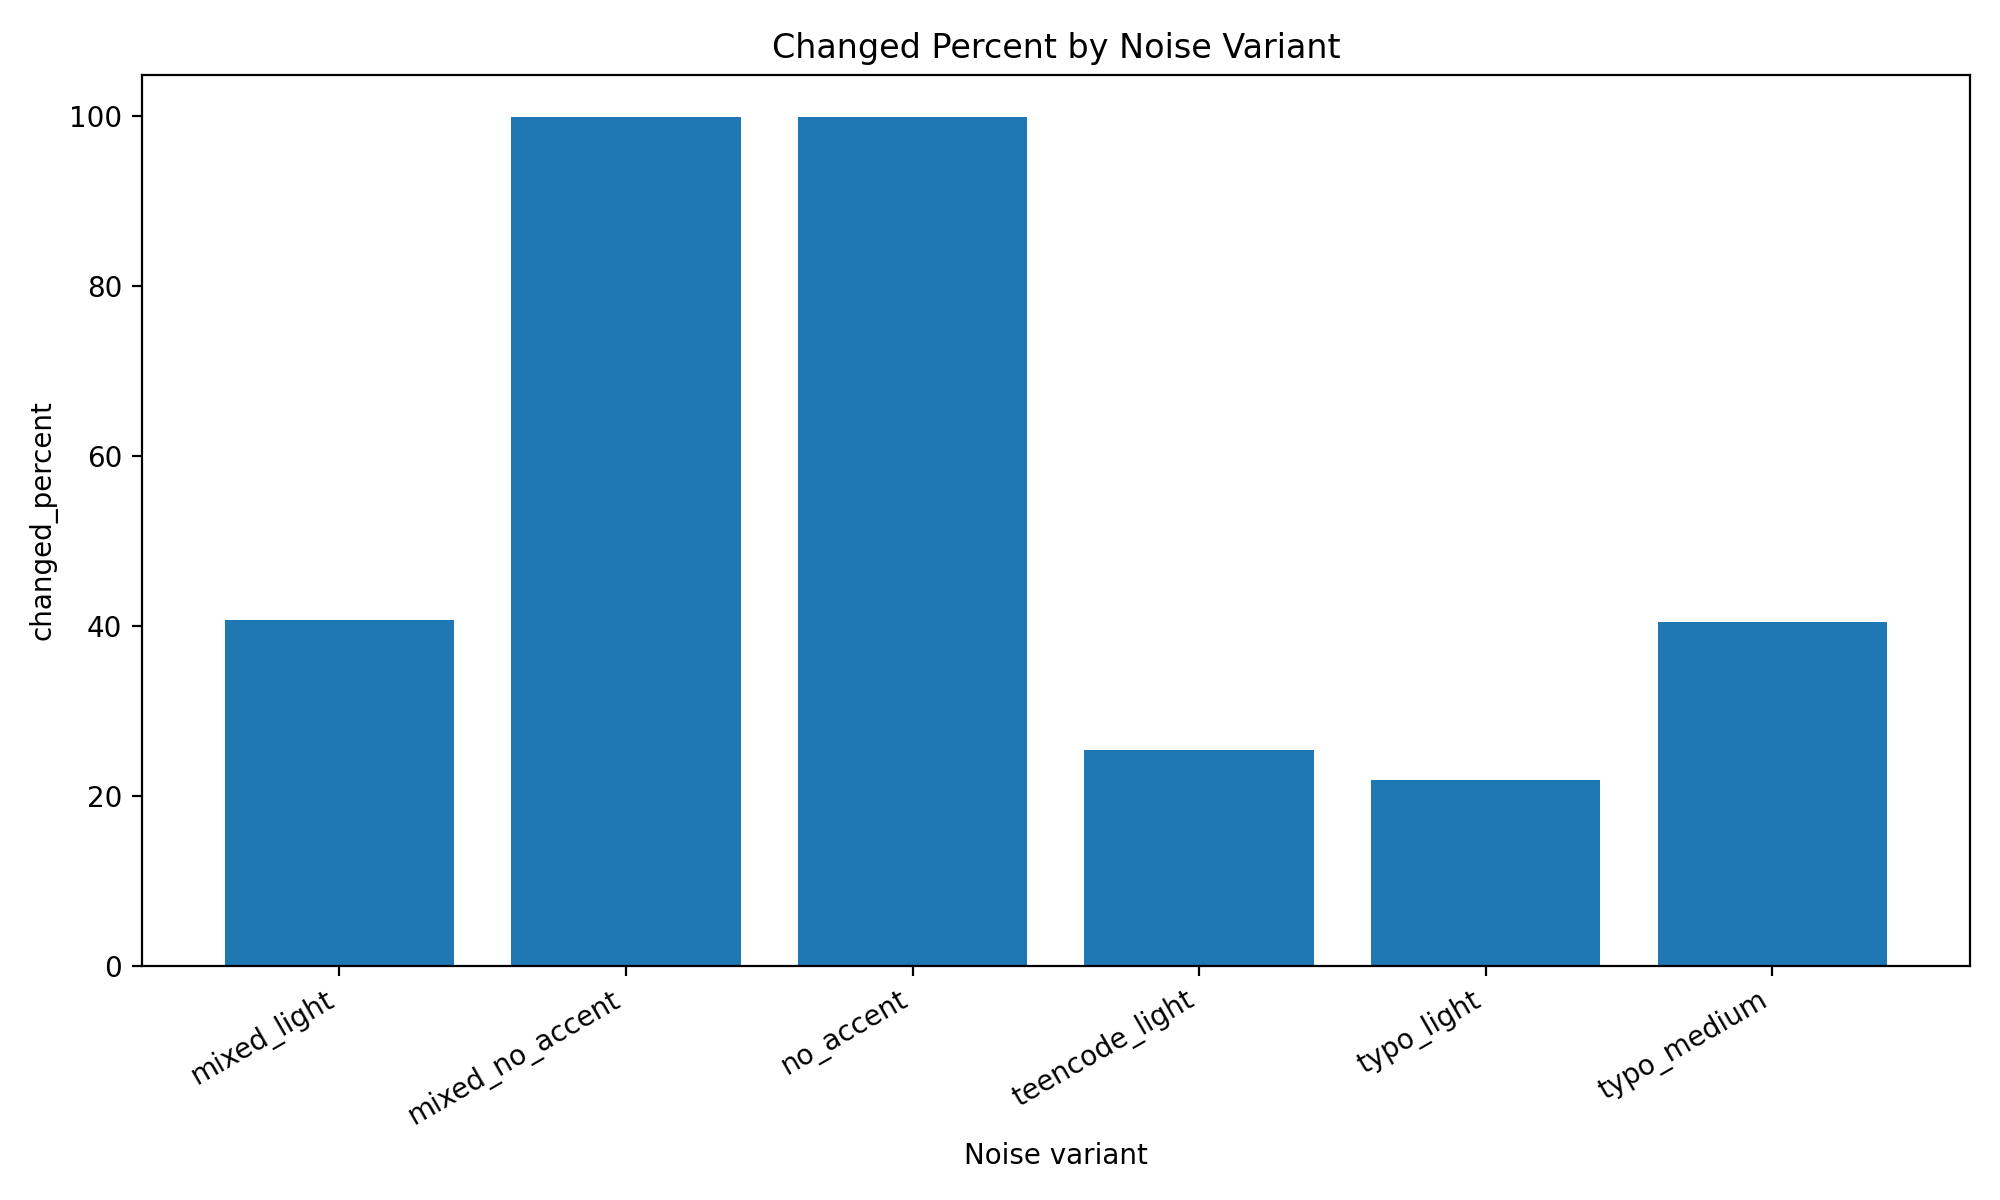

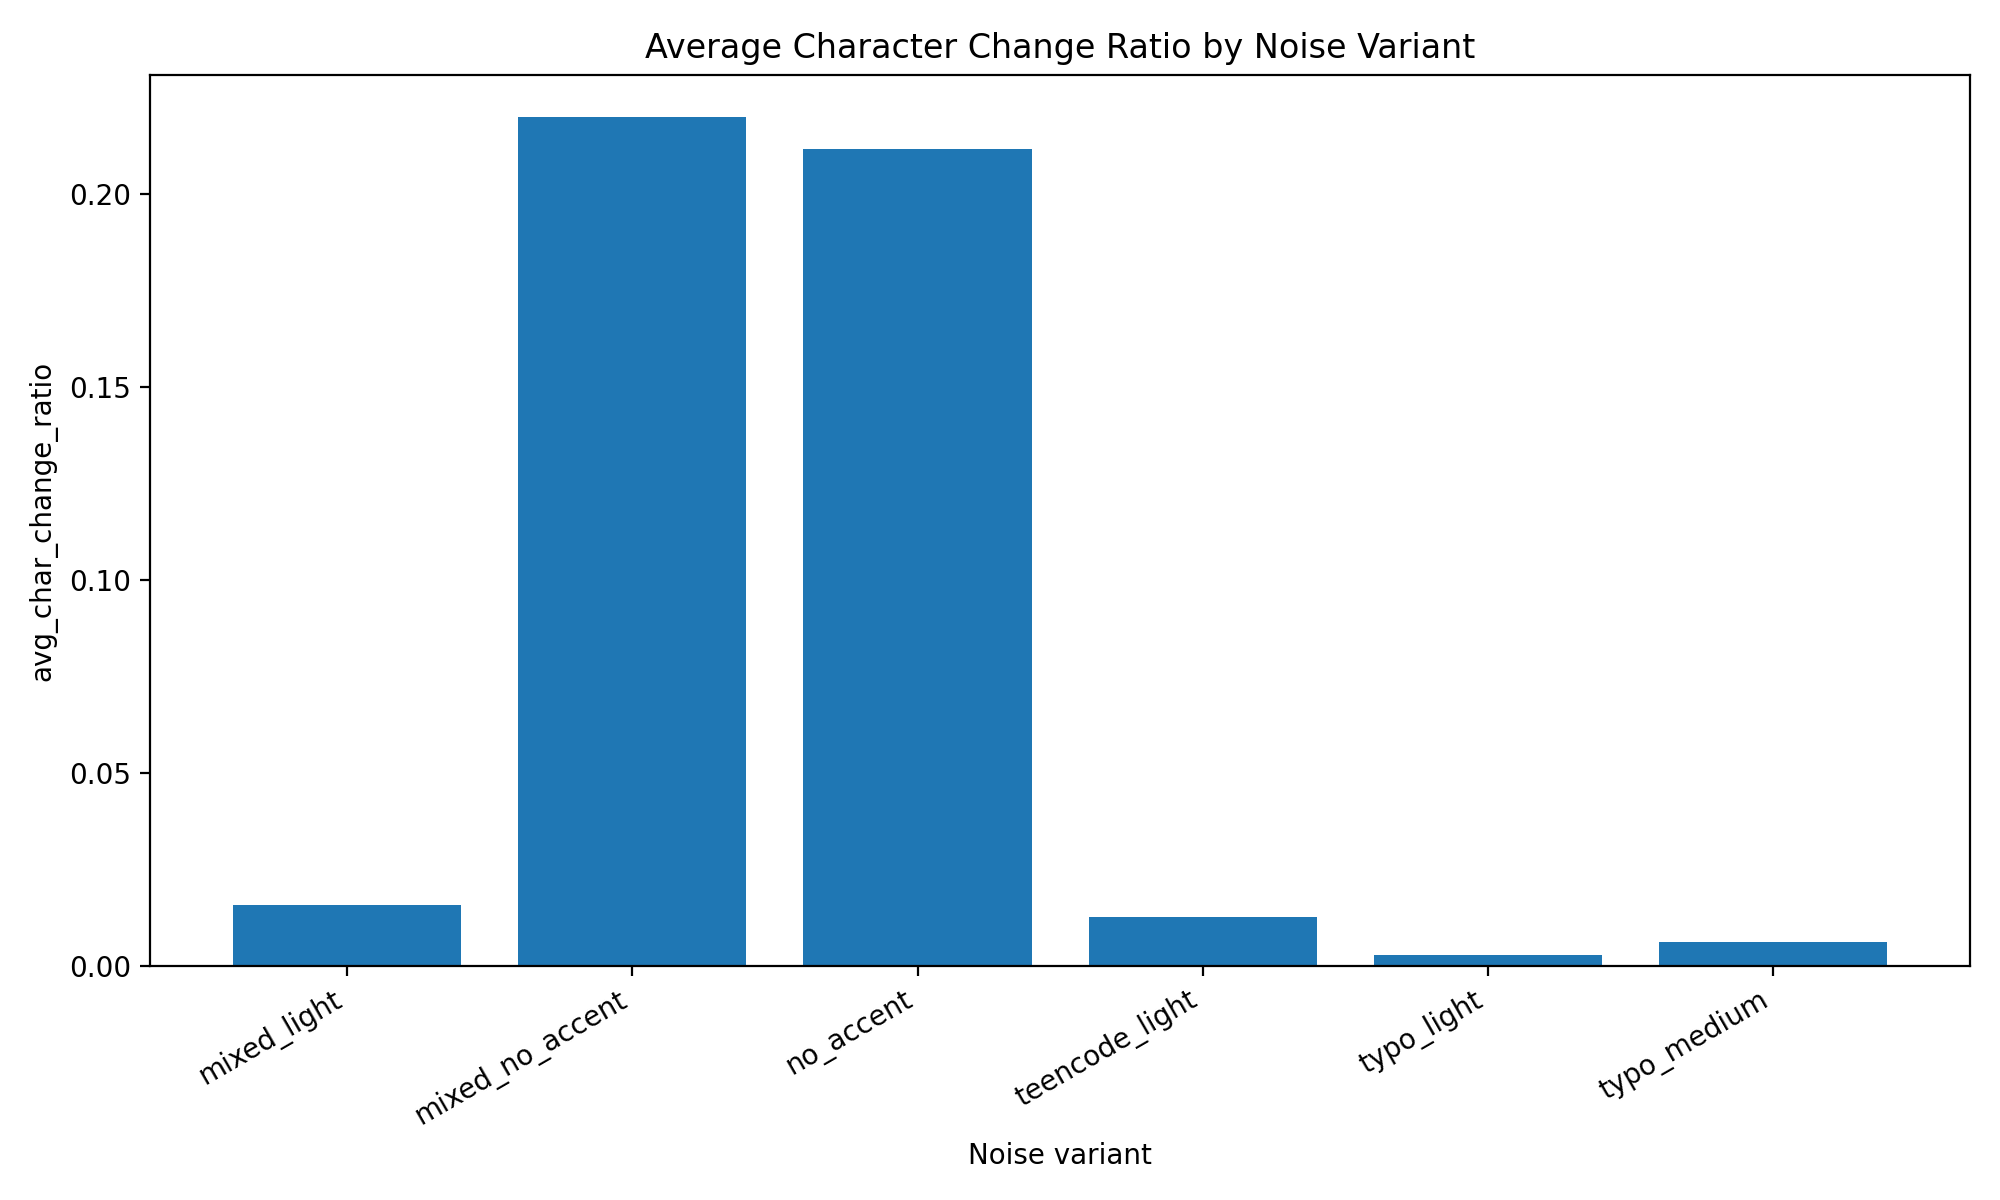

In [5]:
display(Image(filename=str(FIGURES_DIR / "noisy_changed_percent_by_variant.png")))
display(Image(filename=str(FIGURES_DIR / "noisy_char_change_ratio_by_variant.png")))

## 6. Đánh giá từng nhóm noise

Kỳ vọng thiết kế:

```text
clean:
- changed_percent = 0
- avg_char_change_ratio = 0

no_accent:
- changed gần 100%
- avg_char_change_ratio cao
- đây là biến thể mạnh nhưng phổ biến với tiếng Việt phi chuẩn

typo_light / typo_medium:
- changed_percent tăng theo mức độ
- avg_char_change_ratio thấp
- mô phỏng lỗi gõ nhẹ, không phá nghĩa câu quá nhiều

teencode_light:
- changed vừa phải
- thay các cụm như sinh viên → sv, giảng viên → gv, không → ko

mixed_light:
- kết hợp typo + teencode
- không bỏ dấu toàn bộ
- phải nhẹ hơn no_accent

mixed_no_accent:
- kết hợp bỏ dấu + typo + teencode
- là biến thể mạnh hơn mixed_light
```

In [6]:
def get_metric(variant: str, col: str):
    rows = summary_df[summary_df["variant"] == variant]
    if len(rows) == 0:
        return None
    return float(rows.iloc[0][col])

for variant in summary_df["variant"].tolist():
    changed = get_metric(variant, "changed_percent")
    ratio = get_metric(variant, "avg_char_change_ratio")
    display(Markdown(f"- `{variant}`: changed = **{changed:.4f}%**, avg_char_change_ratio = **{ratio:.6f}**"))

# Một số kiểm tra logic nhẹ
if "clean" in summary_df["variant"].values:
    clean_changed = get_metric("clean", "changed_percent")
    if clean_changed != 0:
        display(Markdown("⚠️ `clean` should have 0% changed text."))

if "mixed_light" in summary_df["variant"].values and "no_accent" in summary_df["variant"].values:
    mixed_light_ratio = get_metric("mixed_light", "avg_char_change_ratio")
    no_accent_ratio = get_metric("no_accent", "avg_char_change_ratio")
    if mixed_light_ratio is not None and no_accent_ratio is not None:
        if mixed_light_ratio >= no_accent_ratio * 0.8:
            display(Markdown("⚠️ `mixed_light` is close to `no_accent`. Check whether `remove_diacritics` is accidentally enabled."))
        else:
            display(Markdown("`mixed_light` is clearly lighter than `no_accent`, which is expected."))

- `clean`: changed = **0.0000%**, avg_char_change_ratio = **0.000000**

- `mixed_light`: changed = **40.6822%**, avg_char_change_ratio = **0.015794**

- `mixed_no_accent`: changed = **99.8737%**, avg_char_change_ratio = **0.219922**

- `no_accent`: changed = **99.8737%**, avg_char_change_ratio = **0.211668**

- `teencode_light`: changed = **25.4264%**, avg_char_change_ratio = **0.012741**

- `typo_light`: changed = **21.9204%**, avg_char_change_ratio = **0.002927**

- `typo_medium`: changed = **40.4611%**, avg_char_change_ratio = **0.006423**

`mixed_light` is clearly lighter than `no_accent`, which is expected.

## 7. Ví dụ noisy text

Bảng này dùng để kiểm tra thủ công xem noise có làm hỏng nghĩa hoặc làm sai nhãn không.

In [7]:
examples_df = pd.read_csv(TABLES_DIR / "noisy_text_examples.csv")
display(examples_df.head(50))

,variant,noise_type,noise_level,original_id,original_text,text,char_change_ratio,sentiment_label,sentiment_name,topic_label,topic_name
0,mixed_light,mixed,light,test_2791,môn học này mặc dù phòng đào tạo cho sinh viên...,môn học này mặc dù phòng đào tạo cho sinh viên...,0.024155,0,negative,1,training_program
1,mixed_light,mixed,light,test_2954,cần có giờ ra chơi giữa giờ vì học liên tục nă...,cần có giờ ra chi giữa giờ vì học liên tục năm...,0.038462,0,negative,3,others
2,mixed_light,mixed,light,test_1123,"bài tập thầy cho ít , giải cũng ít , không có ...","bt thầy cho ít , giải cũng ít , không có bài t...",0.042017,0,negative,0,lecturer
3,mixed_light,mixed,light,test_204,giảng viên nhiệt tình dạy dễ hiểu .,gv nhiệt tình dạy dễ hiểu .,0.129032,2,positive,0,lecturer
4,mixed_light,mixed,light,test_148,thầy rất vui và dạy rất kỹ .,thầy rấtt vui và dạy rấtt kỹ .,0.034483,2,positive,0,lecturer
5,mixed_light,mixed,light,test_312,dạy quá nhanh và đôi chút hơi khó hiểu .,dạy quá nhanh và đôi cchút hơi khó hiểu .,0.012346,0,negative,0,lecturer
6,mixed_light,mixed,light,test_1094,"cho nhiều bài tập , cách hướng dẫn , tài liệu ...","cho nhiều bt , cách hướng dẫn , tài lệiu kỹ hơn .",0.067961,0,negative,1,training_program
7,mixed_light,mixed,light,test_2608,"thưa , thầy luôn nhiệt tâm với sinh viên .","thưa , thầy luôn nhiệt tâm với sv .",0.090909,2,positive,0,lecturer
8,mixed_light,mixed,light,test_1817,"giảng viên nhiệt tình , giảng dạy kiến thức th...","gv nhiệt tình , gảing dạy kiến thức thực tiễn .",0.098039,2,positive,0,lecturer
9,mixed_light,mixed,light,test_107,thầy lý thuyết wzjwz223 cũng thường xuyên đi t...,thầy lý thuyết wzjwz223 cũnng thờưng xuyên đi ...,0.029703,0,negative,0,lecturer


## 8. Xem ví dụ theo từng variant

In [8]:
for variant in examples_df["variant"].drop_duplicates().tolist():
    display(Markdown(f"### Variant: `{variant}`"))
    cols = [
        "original_text",
        "text",
        "char_change_ratio",
        "sentiment_name",
        "topic_name",
    ]
    display(examples_df[examples_df["variant"] == variant][cols].head(10))

### Variant: `mixed_light`

,original_text,text,char_change_ratio,sentiment_name,topic_name
0,môn học này mặc dù phòng đào tạo cho sinh viên...,môn học này mặc dù phòng đào tạo cho sinh viên...,0.024155,negative,training_program
1,cần có giờ ra chơi giữa giờ vì học liên tục nă...,cần có giờ ra chi giữa giờ vì học liên tục năm...,0.038462,negative,others
2,"bài tập thầy cho ít , giải cũng ít , không có ...","bt thầy cho ít , giải cũng ít , không có bài t...",0.042017,negative,lecturer
3,giảng viên nhiệt tình dạy dễ hiểu .,gv nhiệt tình dạy dễ hiểu .,0.129032,positive,lecturer
4,thầy rất vui và dạy rất kỹ .,thầy rấtt vui và dạy rấtt kỹ .,0.034483,positive,lecturer
5,dạy quá nhanh và đôi chút hơi khó hiểu .,dạy quá nhanh và đôi cchút hơi khó hiểu .,0.012346,negative,lecturer
6,"cho nhiều bài tập , cách hướng dẫn , tài liệu ...","cho nhiều bt , cách hướng dẫn , tài lệiu kỹ hơn .",0.067961,negative,training_program
7,"thưa , thầy luôn nhiệt tâm với sinh viên .","thưa , thầy luôn nhiệt tâm với sv .",0.090909,positive,lecturer
8,"giảng viên nhiệt tình , giảng dạy kiến thức th...","gv nhiệt tình , gảing dạy kiến thức thực tiễn .",0.098039,positive,lecturer
9,thầy lý thuyết wzjwz223 cũng thường xuyên đi t...,thầy lý thuyết wzjwz223 cũnng thờưng xuyên đi ...,0.029703,negative,lecturer


### Variant: `mixed_no_accent`

,original_text,text,char_change_ratio,sentiment_name,topic_name
20,em rất hài lòng về phương pháp giảng dạy này .,em rat hai long ve phuong phap giang day nay .,0.217391,positive,lecturer
21,dạy sát kiến thức cho việc thi cử .,day sat kien thuc cho viec thi cu .,0.171429,positive,lecturer
22,sinh viên hiểu thầy mới cho về .,sinh vien hieu thay moi cho ve .,0.156250,positive,lecturer
23,dạy hơi chán nhưng chắc tại môn giới thiệu ngà...,day hoi chan nhung chac tai mon gii thieu ngan...,0.233533,negative,lecturer
24,dạy kết hợp với các hoạt động liên quan đến bà...,day ket hop vs cac hoat dong lien quan den bai...,0.248731,negative,lecturer
25,cần thêm bài tập ôn chuyên sâu hơn .,can them bai tap on chuyen sau hon .,0.222222,negative,training_program
26,giáo viên rất nhiệt tình .,giao vien rat nhiet tinh .,0.192308,positive,lecturer
27,nhà trường cần cải tiến thiết bị trong phòng h...,nha truong can cai tien thiet bi trong phong h...,0.214286,negative,facility
28,"giáo viên vui vẻ , giảng dạy nhiệt tình .","giao vien vui ve , giang day nhiet tinh .",0.170732,positive,lecturer
29,"thầy chu đáo , vui vẻ , tận tình .","thay chu dao , vui ve , tan tinh .",0.176471,positive,lecturer


### Variant: `no_accent`

...

,original_text,text,char_change_ratio,sentiment_name,topic_name
60,"nhiều buổi học không có giảng viên , khi liên ...","nhiều buổi học không có giảng viên , khi liên ...",0.036269,negative,training_program
61,nên có những buổi học với giảng viên nước ngoà...,nên có những buổi học vs giảng viên nước ngoài...,0.008798,negative,training_program
62,"giảng viên tận tình , diễn đạt dễ hiểu , ví dụ...","gv tận tình , diễn đạt dễ hiểu , ví dụ đưa ra ...",0.068966,positive,lecturer
63,"thầy dạy rất hay , rất tốt với sinh viên .","thầy dạy rấtt hay , rất tốt với sv .",0.102564,positive,lecturer
64,thực hành xong ít nhất 3 tuần lý thuyết mới họ...,thực hành xong ít nhất 3 tuần lý thuyết mới họ...,0.028736,negative,training_program
65,nội dung thực hành rất hợp lý .,nội dung thực hành rấtt hợp lý .,0.015873,positive,training_program
66,"theo em , chất lượng học ở trung tâm itp rất t...","theo em , chất lượng học ở trung tâm itp rất t...",0.053030,negative,training_program
67,mới đầu tiên em nghĩ thầy khó tính gây áp lực ...,mới đầu tiên em nghĩ thầy khó tính gây áp lực ...,0.007220,positive,lecturer
68,"cô quá chất , đi dạy chỉ cần cái điện thoại .","cô qá chất , đi dạy chỉ cần cái điện thoại .",0.011236,positive,lecturer
69,phần chấm bài thuyết trình quá sơ sài .,phần chấm bài thuyết trình qua sơ sài .,0.025641,negative,lecturer


### Variant: `typo_light`

,original_text,text,char_change_ratio,sentiment_name,topic_name
80,không dạy lướt và áp dụng những phần chưa học ...,không dạy lướt và áp dụg những phần chưa học v...,0.007299,negative,lecturer
81,khả năng truyền đạt tốt và định hướng nghề ngh...,khả năng truyền đạt tốt và địh hướng nghề nghi...,0.009901,positive,lecturer
82,"nội dung học thiên về thực hành , ứng dụng vào...","nội dung học thiên về thực hành , ứng dụng vào...",0.004367,negative,training_program
83,lý thuyết có lẽ thầy rất hay song về bài tập c...,lý thuyết có lẽ thầy rất hay sonng về bài tập ...,0.005076,negative,lecturer
84,không song song với kiến thức được học ở lớp l...,không song song với kiến thức được học ở lớp l...,0.017857,positive,training_program
85,"chỉ cần tổ chức các cuộc thi học thuật , trườn...","chỉ cần tổ chức các cuộc thi học thuật , trườn...",0.009836,negative,training_program
86,giảng viên cần phải giảng và hướng dẫn thực hà...,giảng viiên cần phải giảng và hớưng dẫn thực h...,0.017241,negative,lecturer
87,thầy giảng bài còn hơi nhỏ và lướt hơi nhanh n...,thầy giảng bài còn hơi nhỏ và lướt hơi nhhanh ...,0.006711,negative,lecturer
88,cần có các buổi thực hành trên phòng lab để si...,cần có các bui thực hành trên phòng lab để sin...,0.003413,negative,lecturer
89,"thầy rất chịu khó chép bảng , giúp đỡ nhiệt tì...","tầhy rất cịhu khó chép bảng , giúp đỡ nhiệt tì...",0.040000,positive,lecturer


### Variant: `typo_medium`

,original_text,text,char_change_ratio,sentiment_name,topic_name
100,sử dụng nhiều ví dụ giúp sinh viên nắm kiến th...,sử dụng nhiều ví dụ giúp snih viên nắm kiến th...,0.017857,positive,others
101,"nói thuyết trình , nhưng thực ra các bạn chỉ l...","nói thuyết trình , nhưng thực ra các bạn chỉ l...",0.003367,negative,training_program
102,"giảng viên tâm huyết , nhiệt tình .","giảng viiên tâm huyết , nhiệt tình .",0.014085,positive,lecturer
103,"giảng viên dạy rất nhiệt tình , chỉ bảo tận tì...","giảng viên dạy rất nhiệt tình , chỉ bảo tận tì...",0.009901,positive,lecturer
104,"nội dung bài học đều sát với thực tế , lý thuy...","nội dng bài học đều sát với thực tế , lý thyết...",0.017544,positive,lecturer
105,giáo viên cần thông báo cụ thể các chương thi ...,giáo viên cần thông báo cụ thể các chương thi ...,0.022624,negative,lecturer
106,nâng cấp hệ thống máy tình phòng thực hành .,nâng cấp hệ thống máy tình phòng thực hnh .,0.011494,negative,facility
107,"giảng viên thường nghỉ đột xuất nhiều , phương...","gảing viên thường nghỉ đột xuất nhiều , phương...",0.016667,negative,lecturer
108,"giảng viên cần tích cực đi dạy đầy đủ , gần gũ...","giảng vin cần tích cực đi dạy đầy đủ , gần gũi...",0.009346,negative,lecturer
109,"nhìn chung em hài lòng về môn học này , nên em...","nìhn chung em hài lòng về môn học này , nên em...",0.028986,positive,training_program


## 9. Kiểm tra label preservation

Noisy generation không được đổi nhãn. Các cột label phải được giữ nguyên từ test set gốc.

Ở đây kiểm tra mỗi `original_id` có label nhất quán giữa clean và các noisy variants.

In [9]:
label_cols = ["sentiment_label", "sentiment_name", "topic_label", "topic_name"]

label_check = (
    eval_all.groupby("original_id")[label_cols]
    .nunique()
    .reset_index()
)

violations = label_check[
    (label_check[label_cols] > 1).any(axis=1)
]

print("Label preservation violations:", len(violations))
display(violations.head())

if len(violations) > 0:
    raise ValueError("Some noisy samples changed labels unexpectedly.")

print("Labels are preserved across clean/noisy variants.")

Label preservation violations: 0


,original_id,sentiment_label,sentiment_name,topic_label,topic_name


Labels are preserved across clean/noisy variants.


## 10. Kiểm tra duplicate variant id

Mỗi dòng trong `test_eval_all.csv` nên có `id` riêng.

In [10]:
num_rows = len(eval_all)
num_unique_ids = eval_all["id"].nunique()

print("Rows:", num_rows)
print("Unique ids:", num_unique_ids)

if num_rows != num_unique_ids:
    duplicated_ids = eval_all[eval_all["id"].duplicated(keep=False)]["id"].value_counts()
    display(duplicated_ids.head())
    raise ValueError("Duplicate ids found in test_eval_all.csv")

print("No duplicate ids found.")

Rows: 22162
Unique ids: 22162
No duplicate ids found.


## 11. Kết luận Stage 4

Ghi nhận cho báo cáo:

```text
Stage 4 tạo các phiên bản noisy test set nhằm đánh giá độ bền của mô hình khi gặp tiếng Việt phi chuẩn.
Các loại nhiễu gồm bỏ dấu, lỗi gõ, teencode và nhiễu hỗn hợp.
Chỉ test set được làm nhiễu, train/validation giữ nguyên để mô phỏng tình huống mô hình được học từ dữ liệu sạch nhưng phải xử lý input phi chuẩn.
Các nhãn sentiment và topic được giữ nguyên vì noise chỉ thay đổi bề mặt văn bản, không chủ đích thay đổi ý nghĩa phản hồi.
```

Các biến thể dùng cho evaluation:

```text
clean
no_accent
typo_light
typo_medium
teencode_light
mixed_light
mixed_no_accent
```

Ý nghĩa cho giai đoạn sau:

```text
- Baseline và PhoBERT sẽ được evaluate trên cùng clean/noisy test variants.
- Robustness được đo bằng mức giảm Macro-F1 so với clean test.
- Char-level baseline có thể bền hơn trước typo/teencode.
- PhoBERT cần được kiểm tra kỹ trên no_accent và mixed_no_accent.
```

In [11]:
display(Markdown("### Final Stage 4 summary"))
display(summary_df)

display(Markdown("### Files for next stage"))
for path in [
    NOISY_DIR / "test_eval_all.csv",
    NOISY_DIR / "test_noisy_all.csv",
    TABLES_DIR / "noisy_generation_summary.csv",
    TABLES_DIR / "noisy_text_examples.csv",
]:
    display(Markdown(f"- `{path.relative_to(ROOT)}`"))

### Final Stage 4 summary

,variant,noise_type,noise_level,num_rows,changed_count,unchanged_count,changed_percent,avg_char_change_ratio,p50_char_change_ratio,p95_char_change_ratio,max_char_change_ratio
0,clean,clean,none,3166,0,3166,0.0000,0.000000,0.000000,0.000000,0.000000
1,mixed_light,mixed,light,3166,1288,1878,40.6822,0.015794,0.000000,0.080460,0.530726
2,mixed_no_accent,mixed,medium,3166,3162,4,99.8737,0.219922,0.210526,0.297191,0.942470
3,no_accent,remove_diacritics,medium,3166,3162,4,99.8737,0.211668,0.203390,0.272727,0.870769
4,teencode_light,teencode,light,3166,805,2361,25.4264,0.012741,0.000000,0.076923,0.328431
5,typo_light,typo,light,3166,694,2472,21.9204,0.002927,0.000000,0.018182,0.104790
6,typo_medium,typo,medium,3166,1281,1885,40.4611,0.006423,0.000000,0.027523,0.095238


### Files for next stage

- `data\noisy\test_eval_all.csv`

- `data\noisy\test_noisy_all.csv`

- `outputs\tables\noisy_generation_summary.csv`

- `outputs\tables\noisy_text_examples.csv`

## 12. Stage 4 status

Stage 4 hoàn thành khi:

```text
- test_eval_all.csv có đủ clean + noisy variants.
- Mỗi variant có đúng số dòng bằng test set gốc.
- clean có changed_percent = 0.
- no_accent và mixed_no_accent là nhóm noise mạnh.
- mixed_light nhẹ hơn no_accent.
- Label sentiment/topic được giữ nguyên.
- Có bảng summary, bảng examples, biểu đồ và report.
```

Giai đoạn tiếp theo đề xuất:

```text
Stage 5 — Baseline Robustness Evaluation
```

Lý do:

```text
Đánh giá lại các baseline đã train trên clean data bằng noisy test set.
Sau đó mới đưa PhoBERT lên Kaggle để có cùng chuẩn so sánh clean/noisy.
```